# 01 - Data Analysis

- Inspect raw product and comment datasets.
- Check schema, missing values, duplicates, ratings, and text length.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"

products = pd.read_csv(
    RAW_DIR / "digikala-products.csv",
    low_memory=False,
)

comments = pd.read_csv(
    RAW_DIR / "digikala-comments.csv",
    low_memory=False,
)

print("Products:", products.shape)
print("Comments:", comments.shape)

Products: (1283496, 12)
Comments: (6156289, 15)


## Data quality

- Inspect samples, duplicates, and missing values.

In [2]:
display(products.head())
display(comments.head())

print("Product duplicate rows:", products.duplicated().sum())
print("Product duplicate IDs:", products["id"].duplicated().sum())
print("Comment duplicate rows:", comments.duplicated().sum())
print("Comment duplicate IDs:", comments["id"].duplicated().sum())

,id,title_fa,Rate,Rate_cnt,Category1,Category2,Brand,Price,Seller,Is_Fake,min_price_last_month,sub_category
0,7096438,آبسلانگ مدل s5 بسته 250 عددی,90,4,آبسلانگ,NaN,متفرقه,634800,سلامت ساز راد,False,0,beauty
1,2845119,آبسلانگ مدل M-1 بسته 400 عددی,84,217,آبسلانگ,NaN,متفرقه,818800,مهر افزون,False,0,beauty
2,6117745,آبسلانگ مدل m50 مجموعه 500 عددی,88,14,آبسلانگ,NaN,متفرقه,920000,یانگوم,False,0,beauty
3,1912926,استند ابسلانگ مدل S01,78,25,آبسلانگ,NaN,متفرقه,1100000,بهراد طب بیدار,False,0,beauty
4,6335462,آبسلانگ نوری تسلامد مدل All-in-One,84,25,آبسلانگ,NaN,تسلا مد,1530000,دیجی‌کالا,False,0,beauty


,id,title,body,created_at,rate,recommendation_status,is_buyer,product_id,advantages,disadvantages,likes,dislikes,seller_title,seller_code,true_to_size_rate
0,53672599,پیشنهاد نمیشود,به درد نمیخوره,23 شهریور 1402,1.0,not_recommended,True,252058,NaN,NaN,0,0,دیجی‌کالا,5A52N,NaN
1,9897229,بسته بندی بد,می‌تونست به عنوان یه کالای فرهنگی بهتر بسته بن...,16 تیر 1399,0.0,recommended,True,252058,['تجربه جالبی بود برام '],['بسته بندی جالبی نداشت'],1,0,دیجی‌کالا,5A52N,NaN
2,38074516,برس ریمل,بسته بندیش خوب بود\r\n کاربرد و کیفیتشم خیلی خ...,26 مرداد 1401,0.0,recommended,True,3331597,NaN,NaN,0,0,آرالیا بیوتی,ADM47,NaN
3,18628562,خوبه و خوشرنگ,به نظرم خوبه فقط یکم ظریفه. از رنگش خوشم اومد ...,28 اسفند 1399,0.0,recommended,True,3331329,NaN,NaN,0,0,اینجاست آ,9ZMCZ,NaN
4,53301258,برس رنگ مو,معمولیه اگه واسه خونه رنگ کردن شخصی میخواین او...,12 شهریور 1402,3.0,recommended,True,3255700,NaN,NaN,0,0,گالری آرایشی به سیما,CDWHA,NaN


Product duplicate rows: 323129
Product duplicate IDs: 335144
Comment duplicate rows: 1318
Comment duplicate IDs: 3229


In [3]:
product_missing = (
    products.isna().mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_percent")
)

comment_missing = (
    comments.isna().mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_percent")
)

display(product_missing.head(15).to_frame())
display(comment_missing.head(15).to_frame())

,missing_percent
Category2,16.369977
Seller,0.017374
id,0.000000
title_fa,0.000000
Rate_cnt,0.000000
Rate,0.000000
Brand,0.000000
Category1,0.000000
Price,0.000000
Is_Fake,0.000000


,missing_percent
true_to_size_rate,98.525524
disadvantages,93.303238
advantages,88.496235
title,46.538783
recommendation_status,14.528655
seller_title,4.908493
seller_code,4.908493
body,0.010347
rate,0.000000
created_at,0.000000


## Rating distributions

- Review product and comment rating distributions.

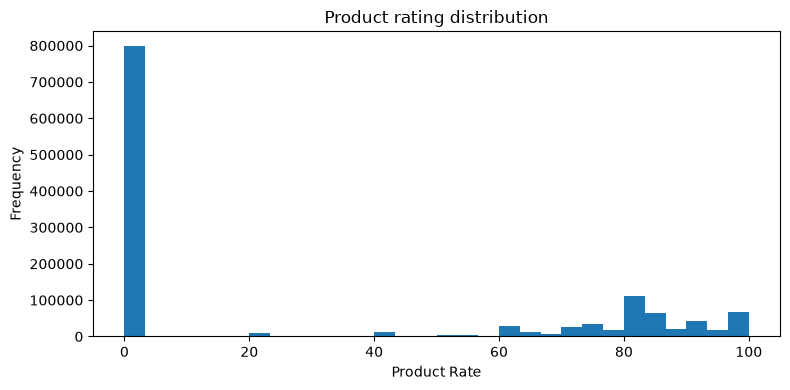

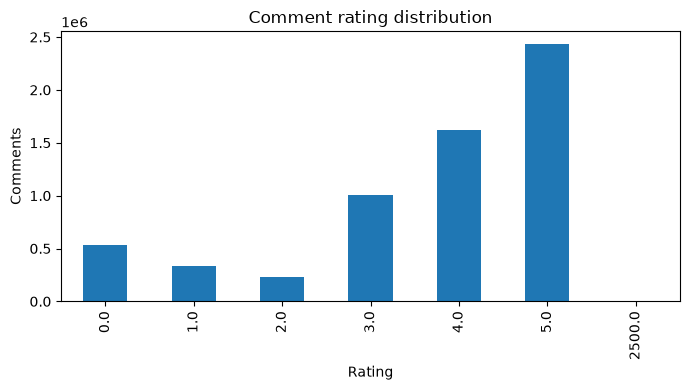

In [4]:
ax = products["Rate"].dropna().plot(
    kind="hist",
    bins=30,
    figsize=(8, 4),
    title="Product rating distribution",
)
ax.set_xlabel("Product Rate")
plt.tight_layout()
plt.show()

comment_rates = (
    comments["rate"]
    .round()
    .value_counts()
    .sort_index()
)

ax = comment_rates.plot(
    kind="bar",
    figsize=(7, 4),
    title="Comment rating distribution",
)
ax.set_xlabel("Rating")
ax.set_ylabel("Comments")
plt.tight_layout()
plt.show()

In [5]:
recommendation_counts = (
    comments["recommendation_status"]
    .value_counts(dropna=False)
)

display(
    recommendation_counts
    .rename("count")
    .to_frame()
)

display(
    pd.crosstab(
        comments["rate"],
        comments["recommendation_status"],
        normalize="index",
    ).round(3)
)

,count
recommendation_status,
recommended,4162839
NaN,894426
no_idea,594121
not_recommended,504903


recommendation_status,no_idea,not_recommended,recommended
rate,,,
0.00,0.041,0.114,0.845
0.05,0.106,0.862,0.032
0.10,0.274,0.645,0.081
0.15,0.439,0.162,0.399
0.20,0.058,0.430,0.512
...,...,...,...
4.85,0.014,0.004,0.982
4.88,0.000,0.000,1.000
4.90,0.013,0.003,0.984


## Review text length

- Inspect comment body length.

count    6.156289e+06
mean     4.839334e+01
std      6.434920e+01
min      0.000000e+00
25%      1.500000e+01
50%      2.900000e+01
75%      5.700000e+01
max      4.000000e+03
Name: body, dtype: float64


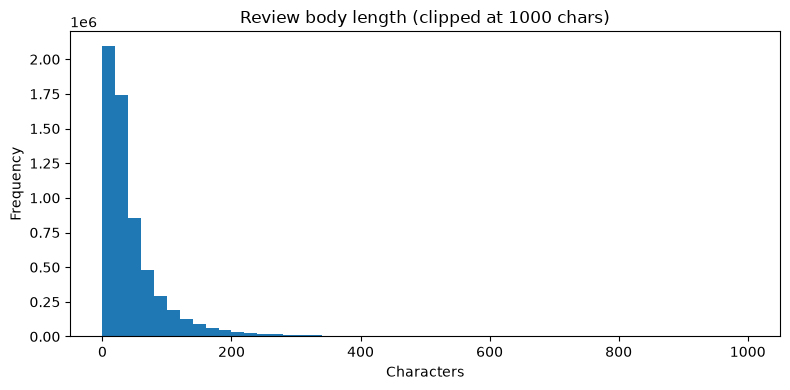

In [6]:
text_length = (
    comments["body"]
    .fillna("")
    .str.len()
)

print(text_length.describe())

ax = text_length.clip(upper=1000).plot(
    kind="hist",
    bins=50,
    figsize=(8, 4),
    title="Review body length (clipped at 1000 chars)",
)
ax.set_xlabel("Characters")
plt.tight_layout()
plt.show()